<a href="https://colab.research.google.com/github/tsilva/aiml-notebooks/blob/main/rnn/001-simple-rnn-from-scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RNN - Simple RNN from Scratch

In this notebook, we build a simple Recurrent Neural Network (RNN) from scratch using PyTorch, **without using high-level modules like `nn.RNN`**.  
We'll walk step by step through how an RNN operates internally by manually defining weight matrices, biases, and performing forward passes through the sequence.

We aim to teach our RNN to predict the next number in a simple linear sequence.  
For example, given a sequence:
```
1, 2, 3, 4, ..., n
```
The model should learn to predict:
```
2, 3, 4, 5, ..., n+1
```


In [229]:
def setup_config():
    n_epochs = 500 # @param {type:"integer"}
    learning_rate = 0.01 # @param {type:"number"}
    seq_length = 10 # @param {type:"integer"}
    input_size = 1 # @param {type:"integer"}
    hidden_size = 16 # @param {type:"integer"}
    output_size = 1 # @param {type:"integer"}
    target_seq_shifts = -1 # @param {type:"integer"}
    batch_size = 1 # @param {type:"integer"}
    activation = 'tanh' # @param ['tanh', 'relu']
    max_grad_norm = 1.0 # @param {type:"number"}
    return {
        'n_epochs' : n_epochs,
        'learning_rate': learning_rate,
        'seq_length': seq_length,
        'input_size': input_size,
        'hidden_size': hidden_size,
        'output_size': output_size,
        'target_seq_shifts' : target_seq_shifts,
        'batch_size': batch_size,
        'activation': activation,
        'max_grad_norm' : max_grad_norm
    }

CONFIG = setup_config()

Let's generate a sequence of numbers:

In [230]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

def generate_sequence(seq_length = None):
    if seq_length is None: seq_length = CONFIG['seq_length']
    start = 1.0
    _start = torch.tensor([start])
    seq = _start + torch.arange(seq_length).float()
    return seq.unsqueeze(-1)

seq = generate_sequence()
seq.shape, seq

(torch.Size([10, 1]),
 tensor([[ 1.],
         [ 2.],
         [ 3.],
         [ 4.],
         [ 5.],
         [ 6.],
         [ 7.],
         [ 8.],
         [ 9.],
         [10.]]))

And let's generate the corrresponding sequence (the same sequence shifted by one position):

In [231]:
def get_target_seq(seq, shifts=None):
  if shifts is None: shifts = CONFIG['target_seq_shifts']
  return torch.roll(seq, shifts=shifts, dims=0)
target = get_target_seq(seq)
target.shape, target

(torch.Size([10, 1]),
 tensor([[ 2.],
         [ 3.],
         [ 4.],
         [ 5.],
         [ 6.],
         [ 7.],
         [ 8.],
         [ 9.],
         [10.],
         [ 1.]]))

Let's defined the model parameters:

In [232]:
def build_model_params(input_size=None, hidden_size=None):
    if input_size is None: input_size = CONFIG['input_size']
    if hidden_size is None: hidden_size = CONFIG['hidden_size']

    Wxh = nn.Parameter(torch.randn(input_size, hidden_size) * 0.1)
    Whh = nn.Parameter(torch.randn(hidden_size, hidden_size) * 0.1)
    Why = nn.Parameter(torch.randn(hidden_size, input_size) * 0.1)
    bh = nn.Parameter(torch.zeros(1, hidden_size))
    by = nn.Parameter(torch.zeros(1, input_size))

    return [Wxh, Whh, Why, bh, by]

model_params = build_model_params()
[Wxh, Whh, Why, bh, by] = model_params

Let's pluck the first value in the sequence to feed into the RNN:

In [233]:
x_t = seq[0]
x_t.shape, x_t

(torch.Size([1]), tensor([1.]))

Let's make sure the input has a batch size dimension (the first):

In [234]:
x_t = x_t.unsqueeze(0)
x_t.shape, x_t

(torch.Size([1, 1]), tensor([[1.]]))

Let's initialize the hidden state:

In [235]:
batch_size = CONFIG['batch_size']
hidden_size = CONFIG['hidden_size']
h = torch.zeros(batch_size, hidden_size)
h.shape, h

(torch.Size([1, 16]),
 tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]]))

And now let's simulate the forward pass of a single input (one item from the sequence). Basically we want to matmul the input with the input weight matrix, then sum the hidden state matmuled with the hidden state weight matrix, then add a hidden state bias, then run a nonlinear activation over the whole thing):

In [236]:
activation = CONFIG['activation']
if activation == 'tanh': activation_fn = torch.tanh
elif activation == 'relu': activation_fn = torch.relu
else: raise ValueError(f'Unknown activation: {activation}')

h = activation_fn(x_t @ Wxh + h @ Whh + bh)
h.shape, h

(torch.Size([1, 16]),
 tensor([[-0.0552, -0.0120, -0.0296,  0.0408, -0.0285,  0.0536, -0.1729,  0.1382,
           0.0347,  0.1798, -0.1229, -0.0445, -0.1446,  0.0381,  0.0415, -0.0311]],
        grad_fn=<TanhBackward0>))

Now that we have the new hidden state, we can calculate the output by matmuling it with the weight matrix for the output and summing the output bias.

In [237]:
y_t = h @ Why + by
y_t.shape, y_t

(torch.Size([1, 1]), tensor([[0.0242]], grad_fn=<AddBackward0>))

Processing the whole sequence is similar, with the nuance that the hidden state calculated from the previous input is going to be part of the calculation for the next input in the sequence, this allows information from the previous input to feed into the next allowing preceding context to inform how the next input will be processed:

In [238]:
seq_length = CONFIG['seq_length']
outputs = []
for t in range(seq_length):
    x_t = seq[t].unsqueeze(0)
    h = activation_fn(x_t @ Wxh + h @ Whh + bh)
    y_t = h @ Why + by
    outputs.append(y_t)
outputs

[tensor([[0.0533]], grad_fn=<AddBackward0>),
 tensor([[0.0726]], grad_fn=<AddBackward0>),
 tensor([[0.1203]], grad_fn=<AddBackward0>),
 tensor([[0.1598]], grad_fn=<AddBackward0>),
 tensor([[0.1931]], grad_fn=<AddBackward0>),
 tensor([[0.2208]], grad_fn=<AddBackward0>),
 tensor([[0.2426]], grad_fn=<AddBackward0>),
 tensor([[0.2596]], grad_fn=<AddBackward0>),
 tensor([[0.2726]], grad_fn=<AddBackward0>),
 tensor([[0.2824]], grad_fn=<AddBackward0>)]

We have collected all our outputs, but we need to have them in a shape matching the sequence target, which is a tensor `(20, 1)`, to do so, we need only to concaneate the list:

In [239]:
outputs = torch.cat(outputs, dim=0)
outputs.shape, outputs

(torch.Size([10, 1]),
 tensor([[0.0533],
         [0.0726],
         [0.1203],
         [0.1598],
         [0.1931],
         [0.2208],
         [0.2426],
         [0.2596],
         [0.2726],
         [0.2824]], grad_fn=<CatBackward0>))

We can now compare the predicted sequence to the target sequence and calculate the loss:

In [240]:
loss_fn = nn.MSELoss()
loss = loss_fn(outputs, target)
loss

tensor(36.2226, grad_fn=<MseLossBackward0>)

We now have everything we need to run a training loop:

Epoch [10/500], Loss: 18.3765
Epoch [20/500], Loss: 9.2604
Epoch [30/500], Loss: 6.5494
Epoch [40/500], Loss: 5.5777
Epoch [50/500], Loss: 5.3517
Epoch [60/500], Loss: 5.3400
Epoch [70/500], Loss: 5.1962
Epoch [80/500], Loss: 4.8444
Epoch [90/500], Loss: 4.4908
Epoch [100/500], Loss: 3.9720
Epoch [110/500], Loss: 3.5696
Epoch [120/500], Loss: 2.9542
Epoch [130/500], Loss: 2.5132
Epoch [140/500], Loss: 2.5262
Epoch [150/500], Loss: 1.7546
Epoch [160/500], Loss: 1.5849
Epoch [170/500], Loss: 1.4896
Epoch [180/500], Loss: 1.4524
Epoch [190/500], Loss: 1.0905
Epoch [200/500], Loss: 0.9306
Epoch [210/500], Loss: 0.8510
Epoch [220/500], Loss: 0.7089
Epoch [230/500], Loss: 0.8893
Epoch [240/500], Loss: 0.6966
Epoch [250/500], Loss: 0.5823
Epoch [260/500], Loss: 0.8903
Epoch [270/500], Loss: 0.6942
Epoch [280/500], Loss: 0.4981
Epoch [290/500], Loss: 0.6421
Epoch [300/500], Loss: 2.1113
Epoch [310/500], Loss: 1.6259
Epoch [320/500], Loss: 0.3788
Epoch [330/500], Loss: 0.3576
Epoch [340/500], L

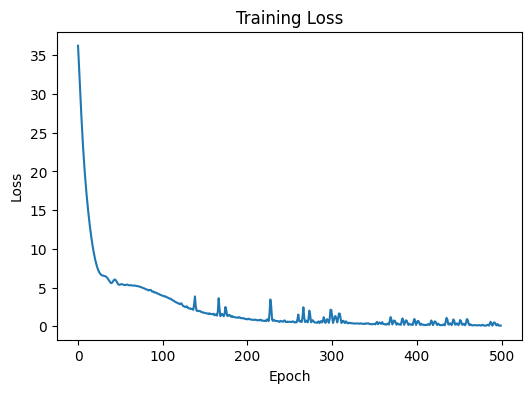

In [241]:
# Hyperparameters
n_epochs = CONFIG['n_epochs']
learning_rate = CONFIG['learning_rate']

loss_fn = nn.MSELoss()

# Optimizer
optimizer = torch.optim.Adam(model_params, lr=learning_rate)

loss_history = []

# Initialize gradient tracking
gradients_over_time = {
    'Wxh': [],
    'Whh': [],
    'Why': [],
    'hidden_state_norms': []
}

for epoch in range(n_epochs):
    seq = generate_sequence()
    target = get_target_seq(seq)

    # Initialize hidden state
    h = torch.zeros(batch_size, hidden_size)

    outputs = []
    hidden_states = []  # For visualization

    for t in range(seq_length):
        x_t = seq[t].unsqueeze(0)  # shape: (1, input_size)
        h = activation_fn(x_t @ Wxh + h @ Whh + bh)

        # Retain gradients of hidden state for each time step
        h.retain_grad()

        y_t = h @ Why + by

        outputs.append(y_t)
        hidden_states.append(h)

    outputs = torch.cat(outputs, dim=0)

    loss = loss_fn(outputs, target)

    optimizer.zero_grad()
    loss.backward()

    max_grad_norm = CONFIG['max_grad_norm']
    if max_grad_norm: torch.nn.utils.clip_grad_norm_(model_params, max_norm=max_grad_norm)

    # Track gradient norms after backward
    gradients_over_time['Wxh'].append(Wxh.grad.norm().item())
    gradients_over_time['Whh'].append(Whh.grad.norm().item())
    gradients_over_time['Why'].append(Why.grad.norm().item())

    # Track hidden state gradient norms per time step
    hidden_state_grad_norms = [h.grad.norm().item() for h in hidden_states]
    gradients_over_time['hidden_state_norms'].append(hidden_state_grad_norms)

    optimizer.step()

    loss_history.append(loss.item())

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch + 1}/{n_epochs}], Loss: {loss.item():.4f}')

# Plot loss curve
plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

The loss has stagnated, indicating that the model has finished learning, let's test its predictions:

In [242]:
outputs=[]
with torch.no_grad():
    seq = generate_sequence()
    target = get_target_seq(seq)
    h = torch.zeros(batch_size, hidden_size)
    predictions = []
    hidden_states = []
    for t in range(seq_length):
        x_t = seq[t].unsqueeze(0)  # shape: (1, input_size)
        h = activation_fn(x_t @ Wxh + h @ Whh + bh)
        y_t = h @ Why + by
        predictions.append(y_t.item())
        hidden_states.append(h.numpy())
[round(x) for x in predictions], target.view(-1).int().tolist()

([2, 3, 4, 5, 6, 7, 8, 9, 10, 1], [2, 3, 4, 5, 6, 7, 8, 9, 10, 1])

The model has failed to learn the sequence, it starts correctly but eventually starts failing later down the sequence, let's analyze how the hidden states behave throughout the sequence:

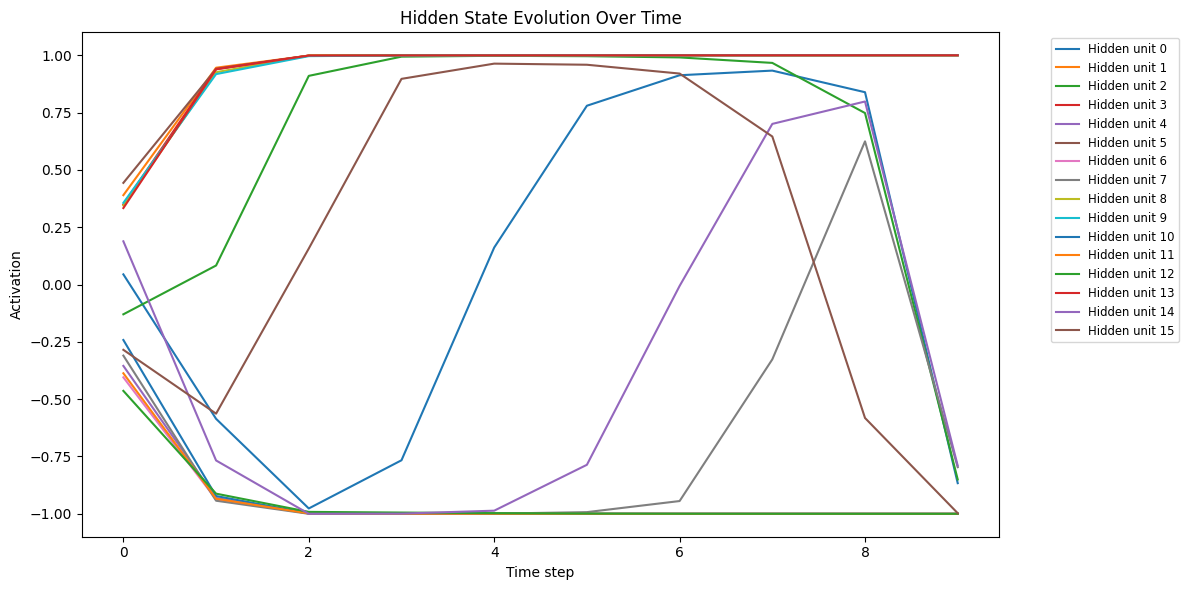

In [243]:
# Visualize hidden state evolution
hidden_states = torch.tensor(hidden_states).squeeze(1).numpy()  # shape: (seq_length, hidden_size)

plt.figure(figsize=(12, 6))
for i in range(hidden_size): plt.plot(hidden_states[:, i], label=f'Hidden unit {i}')
plt.title('Hidden State Evolution Over Time')
plt.xlabel('Time step')
plt.ylabel('Activation')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1, fontsize='small')
plt.tight_layout()
plt.show()

From the graph above we can notice that the hidden states are converging to the extremes of the tanh. Given the flat surface at these extremes, the gradients will tend to zero, meaning there is no learning, this is the vanishing gradient problem. We are unable to backpropagate the loss all the way back through the calculation graph that originated the output and therefore are unable to make all the adjustments we need to minimize that loss.

Let's plot the gradients of these hidden states across time steps:

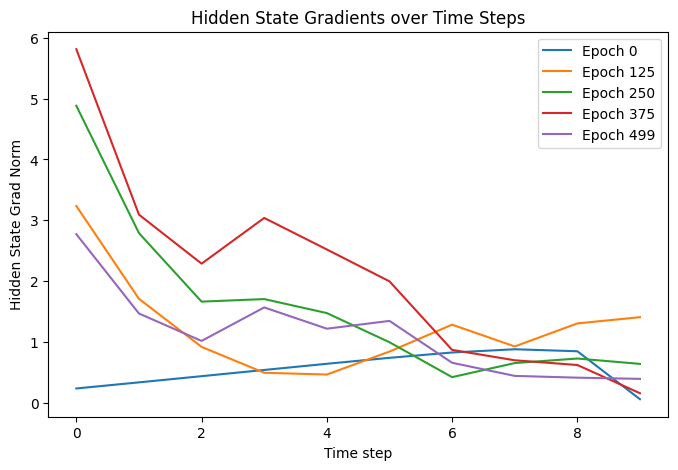

In [244]:
# Dynamically select epochs to plot
total_epochs = len(gradients_over_time['hidden_state_norms'])

# Let's pick evenly spaced epochs: start, early, mid, late, end
epochs_to_plot = [
    0,
    max(1, total_epochs // 4),
    max(1, total_epochs // 2),
    max(1, (3 * total_epochs) // 4),
    total_epochs - 1
]

plt.figure(figsize=(8, 5))
for epoch in epochs_to_plot:
    grad_norms = gradients_over_time['hidden_state_norms'][epoch]
    plt.plot(grad_norms, label=f'Epoch {epoch}')
plt.xlabel('Time step')
plt.ylabel('Hidden State Grad Norm')
plt.title('Hidden State Gradients over Time Steps')
plt.legend()
plt.show()

Notice how hidden state gradient magnitudes get smaller the further back into the sequence we go, again vanishing gradients.

Now let's plot the gradient norms of the weight parameters across epochs:

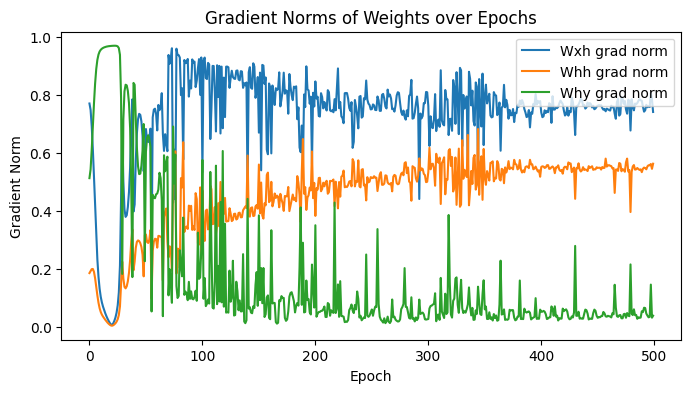

In [245]:
plt.figure(figsize=(8, 4))
plt.plot(gradients_over_time['Wxh'], label='Wxh grad norm')
plt.plot(gradients_over_time['Whh'], label='Whh grad norm')
plt.plot(gradients_over_time['Why'], label='Why grad norm')
plt.xlabel('Epoch')
plt.ylabel('Gradient Norm')
plt.title('Gradient Norms of Weights over Epochs')
plt.legend()
plt.show()

Again, gradient norms collapse to zero. This could be normal if training finished successfully and predictions were good, but in this case in can just be a further hint that gradients are not flowing all the way to the beginning of the calculation graph.

## Next Steps

I suggest you run this notebook again by tweaking these configurations at the start of the notebook and compare the results. Run each of these experiments alone, first don't combine them:

- Enable gradient clipping: this may not work as we're dealing with vanishing gradients, but we can also see some gradient explosions in the graph, and these may be pushing the model to encode parameter values that push the hidden state values to the extremes of the activation function, causing gradients to be zero, it may be that if we stop these spikes by rescaling the gradients to a smaller range, we may have a flow of values that lies within the non-flat surface of the tanh activation function. Set `max_grad_norm` to `1.0` for example, and if you see the training loss still seem to be on a downward trend at the end of training, retrain with a more epochs (remember that by artificially shrinking gradients you may extend training time because updates are smaller so you either have to increase training epochs or learning rate...but increasing epochs is safe as increasing learning rate may make us jump over minima in the error surface).
- Use ReLU as activation function: ReLU doesn't clamp activation values into the range [-1, 1] and since we're dealing with only positive values here, gradients shouldn't collapse with ReLU, and should flow properly, enabling the sequence to be learned. If we were dealing with negative values we could face a similar problem but with dying ReLUs, where basically for any number the activation is always 0, making gradients also zero because there is no difference when parameters are adjusted.